In [9]:
# ============================================================================
# PROPERTY & FINANCIAL PARAMETERS - ADJUST THESE FOR DIFFERENT PROPERTIES
# ============================================================================

# Property details
property_price = 800000         # Total property price
deposit = 200000                 # Your deposit
interest_rate = 4.85             # Annual interest rate (%)
loan_term_years = 30             # Loan term in years

# Ongoing costs (annual)
rates_annual = 6279.37         # Council rates per year
body_corp_annual = 10610.05      # Body corporate fees per year (0 if none)

# Rent comparison
weekly_rent = 600                # What you'd pay in rent per week

# Investment assumptions
property_growth_rate = 0.03      # Expected annual property appreciation (3%)
investment_return_rate = 0.05    # Expected return if deposit invested elsewhere (5%)

# ============================================================================
# CALCULATED VALUES - DO NOT MODIFY
# ============================================================================

P = property_price - deposit     # Loan principal
N = 12 * loan_term_years         # Loan term in months
r = (interest_rate / 100) / 12   # Monthly interest rate
c = (P * r) / (1 - (1 + r)**-N)  # Monthly repayment

C = rates_annual + body_corp_annual  # Total annual ownership costs

annual_rent = weekly_rent * 52
monthly_rent = annual_rent / 12

# Helper functions
def principal_remaining(P, r, c, n):
    return P * (1 + r)**n - c * (((1 + r)**n - 1) / r)

def interest_paid(P, r, c, n):
    return (c * n) - (P - principal_remaining(P, r, c, n))

print("="*70)
print("PROPERTY ANALYSIS SETUP")
print("="*70)
print(f"\n📍 Property: ${property_price:,.0f}")
print(f"   Deposit: ${deposit:,.0f} ({(deposit/property_price)*100:.1f}%)")
print(f"   Loan: ${P:,.0f} ({(P/property_price)*100:.1f}%)")
print(f"   Interest rate: {interest_rate}%")
print(f"\n💰 Monthly costs:")
print(f"   Mortgage payment: ${c:,.2f}")
print(f"   Ownership costs: ${C/12:,.2f}")
print(f"   vs Rent: ${monthly_rent:,.2f}")
print(f"\n📈 Growth assumptions:")
print(f"   Property: {property_growth_rate*100:.1f}% p.a.")
print(f"   Investments: {investment_return_rate*100:.1f}% p.a.")

PROPERTY ANALYSIS SETUP

📍 Property: $800,000
   Deposit: $200,000 (25.0%)
   Loan: $600,000 (75.0%)
   Interest rate: 4.85%

💰 Monthly costs:
   Mortgage payment: $3,166.15
   Ownership costs: $1,407.45
   vs Rent: $2,600.00

📈 Growth assumptions:
   Property: 3.0% p.a.
   Investments: 5.0% p.a.


# Rent vs Buy Analysis

Compare renting vs buying with a mortgage over different time periods.

The analysis considers:
- **Leverage effect:** Property appreciation on full value vs investment returns on deposit only
- **Opportunity cost:** Could invest the deposit elsewhere if renting
- **True costs:** Interest and ownership costs vs rent
- **Equity building:** Principal paydown creates wealth

In [3]:
# Core comparison function
def complete_comparison(n_months, prop_growth=None, inv_return=None):
    """
    Compare renting vs buying over n_months period.
    
    Returns detailed breakdown of both scenarios including leverage effects.
    """
    if prop_growth is None:
        prop_growth = property_growth_rate
    if inv_return is None:
        inv_return = investment_return_rate
        
    years = n_months / 12
    
    # SCENARIO A: RENT + INVEST DEPOSIT
    total_rent = monthly_rent * n_months
    invested_deposit_value = deposit * (1 + inv_return) ** years
    investment_gains = invested_deposit_value - deposit
    
    # SCENARIO B: BUY WITH MORTGAGE
    total_interest = interest_paid(P, r, c, n_months)
    total_ownership_costs = C * (n_months / 12)
    
    property_future_value = property_price * (1 + prop_growth) ** years
    property_capital_gains = property_future_value - property_price
    remaining_loan = principal_remaining(P, r, c, n_months)
    equity = property_future_value - remaining_loan
    
    # NET WEALTH POSITIONS
    rent_net_wealth = invested_deposit_value - total_rent
    buy_net_wealth = equity - total_interest - total_ownership_costs
    
    wealth_difference = buy_net_wealth - rent_net_wealth
    
    return {
        'months': n_months,
        'years': years,
        # Rent scenario
        'total_rent': total_rent,
        'invested_deposit_value': invested_deposit_value,
        'investment_gains': investment_gains,
        'rent_net_wealth': rent_net_wealth,
        # Buy scenario  
        'total_interest': total_interest,
        'total_ownership_costs': total_ownership_costs,
        'property_future_value': property_future_value,
        'property_capital_gains': property_capital_gains,
        'remaining_loan': remaining_loan,
        'equity': equity,
        'buy_net_wealth': buy_net_wealth,
        # Comparison
        'wealth_difference': wealth_difference,
        'better_option': 'Buy' if wealth_difference > 0 else 'Rent'
    }

## 2-Year Analysis: Tax-Free Exit in NZ

After 2 years, you can sell tax-free in NZ (no CGT after bright-line test).

In [4]:
# 2-year comparison
result_2y = complete_comparison(24)

print("="*70)
print("2-YEAR ANALYSIS (Tax-free exit in NZ)")
print("="*70)

print(f"\nSCENARIO A: RENT + INVEST ${deposit:,.0f}")
print(f"  Rent paid: ${result_2y['total_rent']:,.2f}")
print(f"  Deposit grows to: ${result_2y['invested_deposit_value']:,.2f}")
print(f"  Investment gains: ${result_2y['investment_gains']:,.2f}")
print(f"  Net wealth: ${result_2y['rent_net_wealth']:,.2f}\n")

print(f"SCENARIO B: BUY & SELL after 2 years")
print(f"  Interest paid: ${result_2y['total_interest']:,.2f}")
print(f"  Ownership costs: ${result_2y['total_ownership_costs']:,.2f}")
print(f"  Property value: ${result_2y['property_future_value']:,.2f}")
print(f"  Capital gains: ${result_2y['property_capital_gains']:,.2f}")
print(f"  Loan remaining: ${result_2y['remaining_loan']:,.2f}")
print(f"  Equity: ${result_2y['equity']:,.2f}")
print(f"  Net wealth: ${result_2y['buy_net_wealth']:,.2f}\n")

print("="*70)
if result_2y['wealth_difference'] > 0:
    print(f"✓ BUYING is ${result_2y['wealth_difference']:,.2f} better!")
else:
    print(f"✗ RENTING is ${-result_2y['wealth_difference']:,.2f} better")

print(f"\nROI on ${deposit:,.0f}:")
roi_rent = (result_2y['rent_net_wealth'] / deposit - 1) * 100
roi_buy = (result_2y['buy_net_wealth'] / deposit - 1) * 100
print(f"  Rent: {roi_rent:.1f}% ({roi_rent/2:.1f}% p.a.)")
print(f"  Buy: {roi_buy:.1f}% ({roi_buy/2:.1f}% p.a.)")

2-YEAR ANALYSIS (Tax-free exit in NZ)

SCENARIO A: RENT + INVEST $200,000
  Rent paid: $62,400.00
  Deposit grows to: $220,500.00
  Investment gains: $20,500.00
  Net wealth: $158,100.00

SCENARIO B: BUY & SELL after 2 years
  Interest paid: $57,348.21
  Ownership costs: $33,778.84
  Property value: $848,720.00
  Capital gains: $48,720.00
  Loan remaining: $581,360.59
  Equity: $267,359.41
  Net wealth: $176,232.36

✓ BUYING is $18,132.36 better!

ROI on $200,000:
  Rent: -21.0% (-10.5% p.a.)
  Buy: -11.9% (-5.9% p.a.)


In [5]:
# Calculate required income (after-tax) for 50% housing rule
monthly_mortgage = c
monthly_ownership = C / 12
monthly_total_buy = monthly_mortgage + monthly_ownership

# Income required for each option (if 50% goes to housing)
income_required_rent = monthly_rent * 2
income_required_buy = monthly_total_buy * 2

# Use the higher requirement * 2 to give comfortable buffer
income_net_monthly = max(income_required_rent, income_required_buy)

print("="*70)
print("INCOME CALCULATION (50% HOUSING RULE)")
print("="*70)
print(f"\n💰 Monthly costs:")
print(f"   Rent: ${monthly_rent:,.2f}")
print(f"   Buy (mortgage + ownership): ${monthly_total_buy:,.2f}")

print(f"\n📊 Income required (after-tax) if 50% goes to housing:")
print(f"   To afford rent: ${income_required_rent:,.2f}/month")
print(f"   To afford buy: ${income_required_buy:,.2f}/month")

print(f"\n✅ Using comfortable income level:")
print(f"   After-tax monthly: ${income_net_monthly:,.2f}")
print(f"   After-tax annual: ${income_net_monthly * 12:,.2f}")
print(f"\n   Housing as % of income:")
print(f"   - If renting: {(monthly_rent / income_net_monthly * 100):.1f}%")
print(f"   - If buying: {(monthly_total_buy / income_net_monthly * 100):.1f}%")

INCOME CALCULATION (50% HOUSING RULE)

💰 Monthly costs:
   Rent: $2,600.00
   Buy (mortgage + ownership): $4,573.60

📊 Income required (after-tax) if 50% goes to housing:
   To afford rent: $5,200.00/month
   To afford buy: $9,147.21/month

✅ Using comfortable income level:
   After-tax monthly: $9,147.21
   After-tax annual: $109,766.46

   Housing as % of income:
   - If renting: 28.4%
   - If buying: 50.0%


## Income Analysis: 50% Housing Rule

Calculate required income assuming 50% of after-tax income goes to housing.

## Fair Comparison: Investing the Difference

In the rent scenario, you save money each month (buy cost - rent cost) and invest that difference.

In [6]:
# Fair comparison using calculated income
def fair_comparison_with_income(income_net_monthly, n_months, prop_growth=None, inv_return=None):
    """
    Fair comparison where you earn the same income in both scenarios.
    The rent scenario invests the DIFFERENCE between buy cost and rent cost monthly.
    Income is AFTER-TAX.
    """
    if prop_growth is None:
        prop_growth = property_growth_rate
    if inv_return is None:
        inv_return = investment_return_rate
    
    years = n_months / 12
    
    # SCENARIO A: RENT + INVEST DEPOSIT + INVEST SAVINGS (buy_cost - rent_cost)
    monthly_savings = monthly_total_buy - monthly_rent  # What you SAVE by renting instead of buying
    
    # Deposit grows
    invested_deposit_value = deposit * (1 + inv_return) ** years
    
    # Monthly savings compounds (future value of annuity)
    monthly_return = (1 + inv_return) ** (1/12) - 1
    if monthly_savings > 0:
        savings_invested = monthly_savings * (((1 + monthly_return) ** n_months - 1) / monthly_return)
    else:
        savings_invested = 0
    
    total_wealth_rent = invested_deposit_value + savings_invested
    
    # SCENARIO B: BUY WITH MORTGAGE
    # Property equity
    property_future_value = property_price * (1 + prop_growth) ** years
    remaining_loan = principal_remaining(P, r, c, n_months)
    equity = property_future_value - remaining_loan
    
    total_wealth_buy = equity
    
    wealth_difference = total_wealth_buy - total_wealth_rent
    
    return {
        'months': n_months,
        'years': years,
        'income_net_monthly': income_net_monthly,
        # Rent scenario
        'monthly_rent': monthly_rent,
        'monthly_savings': monthly_savings,
        'invested_deposit_value': invested_deposit_value,
        'savings_invested': savings_invested,
        'total_wealth_rent': total_wealth_rent,
        # Buy scenario
        'monthly_total_buy': monthly_total_buy,
        'equity': equity,
        'total_wealth_buy': total_wealth_buy,
        # Comparison
        'wealth_difference': wealth_difference,
        'better_option': 'Buy' if wealth_difference > 0 else 'Rent'
    }

# Run comparison with calculated income
result_fair = fair_comparison_with_income(income_net_monthly, 24)

print("="*70)
print("FAIR COMPARISON: SAME INCOME, INVEST THE DIFFERENCE")
print("="*70)
print(f"\nMonthly net income: ${result_fair['income_net_monthly']:,.2f} (after-tax)")

print(f"\n{'SCENARIO A: RENT':<40}")
print(f"  Monthly rent: ${result_fair['monthly_rent']:,.2f}")
print(f"  Monthly savings vs buying: ${result_fair['monthly_savings']:,.2f}")
print(f"  ─────────────────────────")
print(f"  Initial deposit grows to: ${result_fair['invested_deposit_value']:,.2f}")
print(f"  + Monthly savings invested: ${result_fair['savings_invested']:,.2f}")
print(f"  = TOTAL WEALTH: ${result_fair['total_wealth_rent']:,.2f}")

print(f"\n{'SCENARIO B: BUY':<40}")
print(f"  Monthly mortgage + costs: ${result_fair['monthly_total_buy']:,.2f}")
print(f"  ─────────────────────────")
print(f"  Equity in property: ${result_fair['equity']:,.2f}")
print(f"  = TOTAL WEALTH: ${result_fair['total_wealth_buy']:,.2f}")

print("\n" + "="*70)
if result_fair['wealth_difference'] > 0:
    print(f"✓ BUYING is ${result_fair['wealth_difference']:,.2f} better!")
    pct = (result_fair['wealth_difference'] / result_fair['total_wealth_rent']) * 100
    print(f"  That's {pct:.1f}% more wealth")
else:
    print(f"✗ RENTING is ${-result_fair['wealth_difference']:,.2f} better!")
    pct = (-result_fair['wealth_difference'] / result_fair['total_wealth_buy']) * 100
    print(f"  That's {pct:.1f}% more wealth")

print(f"\n💡 Key insight:")
print(f"   Renting saves ${result_fair['monthly_savings']:,.2f}/month vs buying")
print(f"   Over 2 years, investing that saves you ${result_fair['savings_invested']:,.2f}")
print(f"   But property leverage gives you ${result_fair['equity']:,.2f} in equity")
print(f"   vs ${result_fair['total_wealth_rent']:,.2f} total from renting + investing")

# Calculate ROI for both
roi_rent = (result_fair['total_wealth_rent'] / deposit - 1) * 100
roi_buy = (result_fair['total_wealth_buy'] / deposit - 1) * 100
print(f"\n📊 ROI on your ${deposit:,.0f} deposit:")
print(f"   Rent + invest savings: {roi_rent:.1f}% ({roi_rent/2:.1f}% p.a.)")
print(f"   Buy: {roi_buy:.1f}% ({roi_buy/2:.1f}% p.a.)")

FAIR COMPARISON: SAME INCOME, INVEST THE DIFFERENCE

Monthly net income: $9,147.21 (after-tax)

SCENARIO A: RENT                        
  Monthly rent: $2,600.00
  Monthly savings vs buying: $1,973.60
  ─────────────────────────
  Initial deposit grows to: $220,500.00
  + Monthly savings invested: $49,653.44
  = TOTAL WEALTH: $270,153.44

SCENARIO B: BUY                         
  Monthly mortgage + costs: $4,573.60
  ─────────────────────────
  Equity in property: $267,359.41
  = TOTAL WEALTH: $267,359.41

✗ RENTING is $2,794.03 better!
  That's 1.0% more wealth

💡 Key insight:
   Renting saves $1,973.60/month vs buying
   Over 2 years, investing that saves you $49,653.44
   But property leverage gives you $267,359.41 in equity
   vs $270,153.44 total from renting + investing

📊 ROI on your $200,000 deposit:
   Rent + invest savings: 35.1% (17.5% p.a.)
   Buy: 33.7% (16.8% p.a.)


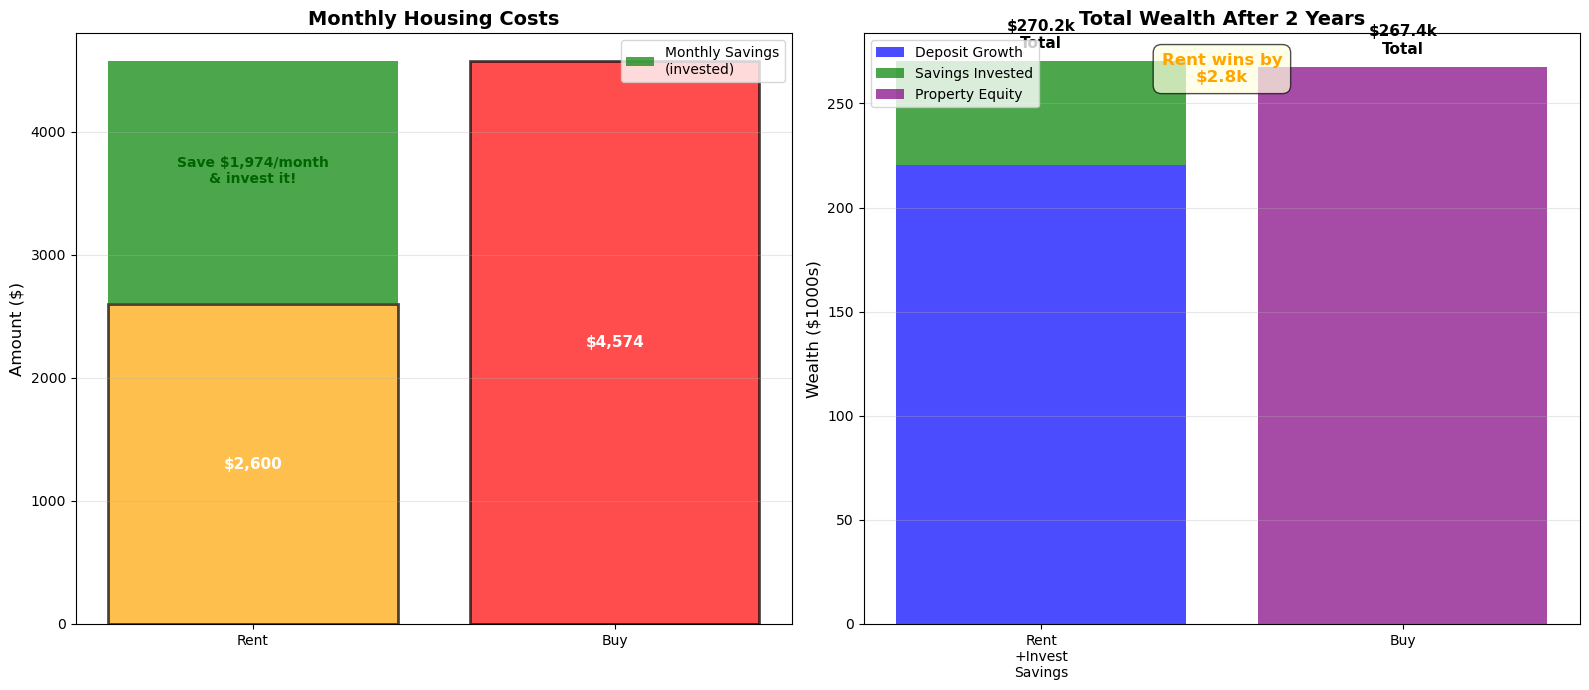


BREAKDOWN: Where does the wealth come from?

Rent scenario total: $270,153
  = $220,500 (deposit growth)
  + $49,653 (monthly savings invested)

Buy scenario total: $267,359
  = $267,359 (equity)

💰 Property equity is $46,859 higher than deposit growth
   But you invested $49,653 in monthly savings
   Net advantage: $-2,794

🎯 Property LEVERAGE effect:
   Your $200,000 controls a $800,000 asset
   3.0% growth on $800,000 = $48,000 over 2 years
   vs 5.0% growth on $200,000 + savings = $70,153 gains


In [7]:
# Visualize the fair comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# LEFT: Monthly cash flow comparison
ax1.set_title(f'Monthly Housing Costs', fontsize=14, fontweight='bold')
categories = ['Rent', 'Buy']
costs = [result_fair['monthly_rent'], result_fair['monthly_total_buy']]
colors_bar = ['orange', 'red']

bars = ax1.bar(categories, costs, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)

# Show the savings
ax1.bar(['Rent'], [result_fair['monthly_savings']], 
        bottom=[result_fair['monthly_rent']], 
        color='green', alpha=0.7, label='Monthly Savings\n(invested)')

ax1.set_ylabel('Amount ($)', fontsize=12)
ax1.axhline(y=0, color='black', linewidth=0.5)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Add cost labels
for i, (cat, cost) in enumerate(zip(categories, costs)):
    ax1.text(i, cost/2, f'${cost:,.0f}', 
            ha='center', va='center', fontsize=11, fontweight='bold', color='white')

# Add savings annotation
ax1.annotate(f'Save ${result_fair["monthly_savings"]:,.0f}/month\n& invest it!', 
            xy=(0, result_fair['monthly_rent'] + result_fair['monthly_savings']/2), 
            fontsize=10, fontweight='bold', color='darkgreen', ha='center')

# RIGHT: Final wealth comparison
ax2.set_title('Total Wealth After 2 Years', fontsize=14, fontweight='bold')
scenarios = ['Rent\n+Invest\nSavings', 'Buy']
wealth_values = [result_fair['total_wealth_rent']/1000, result_fair['total_wealth_buy']/1000]

# Stacked bars showing components
ax2.bar([0], [result_fair['invested_deposit_value']/1000], 
        color='blue', alpha=0.7, label='Deposit Growth')
ax2.bar([0], [result_fair['savings_invested']/1000], 
        bottom=[result_fair['invested_deposit_value']/1000],
        color='green', alpha=0.7, label='Savings Invested')
ax2.bar([1], [result_fair['equity']/1000], 
        color='purple', alpha=0.7, label='Property Equity')

ax2.set_ylabel('Wealth ($1000s)', fontsize=12)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(scenarios)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3, axis='y')

# Add total labels
for i, val in enumerate(wealth_values):
    ax2.text(i, val + 5, f'${val:.1f}k\nTotal', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Show difference
diff = result_fair['wealth_difference']
if diff > 0:
    ax2.annotate(f'Buy wins by\n${diff/1000:.1f}k', 
                xy=(0.5, max(wealth_values) - 10), 
                fontsize=12, fontweight='bold', color='green', ha='center',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.7))
else:
    ax2.annotate(f'Rent wins by\n${-diff/1000:.1f}k', 
                xy=(0.5, max(wealth_values) - 10), 
                fontsize=12, fontweight='bold', color='orange', ha='center',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("BREAKDOWN: Where does the wealth come from?")
print("="*70)
print(f"\nRent scenario total: ${result_fair['total_wealth_rent']:,.0f}")
print(f"  = ${result_fair['invested_deposit_value']:,.0f} (deposit growth)")
print(f"  + ${result_fair['savings_invested']:,.0f} (monthly savings invested)")

print(f"\nBuy scenario total: ${result_fair['total_wealth_buy']:,.0f}")
print(f"  = ${result_fair['equity']:,.0f} (equity)")

print(f"\n💰 Property equity is ${result_fair['equity'] - result_fair['invested_deposit_value']:,.0f} higher than deposit growth")
print(f"   But you invested ${result_fair['savings_invested']:,.0f} in monthly savings")
print(f"   Net advantage: ${result_fair['wealth_difference']:,.0f}")

print(f"\n🎯 Property LEVERAGE effect:")
print(f"   Your ${deposit:,.0f} controls a ${property_price:,.0f} asset")
print(f"   {property_growth_rate*100:.1f}% growth on ${property_price:,.0f} = ${property_price * property_growth_rate * 2:,.0f} over 2 years")
print(f"   vs {investment_return_rate*100:.1f}% growth on ${deposit:,.0f} + savings = ${result_fair['total_wealth_rent'] - deposit:,.0f} gains")

# Reverse Engineering: Find the Break-Even Property Price

Instead of asking "is this property a good buy?", let's ask:
- **What property price makes buying equal to renting?**
- **How sensitive is this to ongoing costs (rates, body corp)?**

We'll solve for the property price where buying and renting yield the same wealth after 2 years.

In [10]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

def wealth_difference_at_price(property_price_test, 
                               deposit_fixed, 
                               weekly_rent_fixed, 
                               rates_annual_fixed, 
                               body_corp_annual_fixed,
                               interest_rate_fixed,
                               loan_term_years_fixed,
                               n_months,
                               prop_growth,
                               inv_return):
    """
    Calculate wealth difference (buy - rent) for a given property price.
    Returns 0 when buying and renting are equal.
    """
    # Recalculate all values for this property price
    P_test = property_price_test - deposit_fixed
    N_test = 12 * loan_term_years_fixed
    r_test = (interest_rate_fixed / 100) / 12
    c_test = (P_test * r_test) / (1 - (1 + r_test)**-N_test)
    
    C_test = rates_annual_fixed + body_corp_annual_fixed
    monthly_total_buy_test = c_test + C_test / 12
    
    annual_rent_test = weekly_rent_fixed * 52
    monthly_rent_test = annual_rent_test / 12
    
    years = n_months / 12
    
    # Calculate income (using the higher of rent or buy * 2 for 50% rule)
    income_net_monthly_test = max(monthly_rent_test * 2, monthly_total_buy_test * 2)
    
    # RENT SCENARIO
    monthly_savings_test = monthly_total_buy_test - monthly_rent_test
    invested_deposit_value_test = deposit_fixed * (1 + inv_return) ** years
    
    monthly_return = (1 + inv_return) ** (1/12) - 1
    if monthly_savings_test > 0:
        savings_invested_test = monthly_savings_test * (((1 + monthly_return) ** n_months - 1) / monthly_return)
    else:
        savings_invested_test = 0
    
    total_wealth_rent_test = invested_deposit_value_test + savings_invested_test
    
    # BUY SCENARIO
    property_future_value_test = property_price_test * (1 + prop_growth) ** years
    remaining_loan_test = P_test * (1 + r_test)**n_months - c_test * (((1 + r_test)**n_months - 1) / r_test)
    equity_test = property_future_value_test - remaining_loan_test
    
    total_wealth_buy_test = equity_test
    
    return total_wealth_buy_test - total_wealth_rent_test


# Find break-even property price for the 2-year scenario
# Start with current property price as initial guess
initial_guess = property_price

breakeven_price = fsolve(
    wealth_difference_at_price,
    initial_guess,
    args=(deposit, weekly_rent, rates_annual, body_corp_annual, 
          interest_rate, loan_term_years, 24, 
          property_growth_rate, investment_return_rate)
)[0]

# Calculate the loan size at break-even
breakeven_loan = breakeven_price - deposit

print("="*70)
print("BREAK-EVEN ANALYSIS (2 Years)")
print("="*70)
print(f"\n🎯 Break-even property price: ${breakeven_price:,.0f}")
print(f"   Loan size at break-even: ${breakeven_loan:,.0f}")
print(f"   Current property price: ${property_price:,.0f}")
print(f"   Current loan size: ${P:,.0f}")

if property_price > breakeven_price:
    print(f"\n✓ Current property is ${property_price - breakeven_price:,.0f} ABOVE break-even")
    print(f"  ➜ Buying is favorable")
else:
    print(f"\n✗ Current property is ${breakeven_price - property_price:,.0f} BELOW break-even")
    print(f"  ➜ Renting is favorable")

print(f"\n💡 Interpretation:")
print(f"   At ${breakeven_price:,.0f}, buying and renting yield the same wealth")
print(f"   Above this price: leverage effect outweighs costs → buying wins")
print(f"   Below this price: costs outweigh leverage effect → renting wins")

BREAK-EVEN ANALYSIS (2 Years)

🎯 Break-even property price: $731,511
   Loan size at break-even: $531,511
   Current property price: $800,000
   Current loan size: $600,000

✓ Current property is $68,489 ABOVE break-even
  ➜ Buying is favorable

💡 Interpretation:
   At $731,511, buying and renting yield the same wealth
   Above this price: leverage effect outweighs costs → buying wins
   Below this price: costs outweigh leverage effect → renting wins


## Sensitivity Analysis: Ongoing Costs

How does the break-even price change with different ongoing costs (rates + body corp)?

In [11]:
# Test different levels of ongoing costs
current_ongoing = rates_annual + body_corp_annual

# Test from 50% to 150% of current costs
cost_multipliers = np.linspace(0.5, 1.5, 11)
breakeven_prices = []
breakeven_loans = []

print("="*70)
print("SENSITIVITY: How ongoing costs affect break-even property price")
print("="*70)
print(f"\nCurrent annual costs: ${current_ongoing:,.0f} (rates + body corp)")
print("\n{'Ongoing Costs':<25} {'Break-Even Price':<20} {'Break-Even Loan':<20}")
print("-"*70)

for multiplier in cost_multipliers:
    test_ongoing = current_ongoing * multiplier
    # Split proportionally between rates and body corp
    test_rates = rates_annual * multiplier
    test_body_corp = body_corp_annual * multiplier
    
    try:
        test_breakeven = fsolve(
            wealth_difference_at_price,
            property_price,  # initial guess
            args=(deposit, weekly_rent, test_rates, test_body_corp, 
                  interest_rate, loan_term_years, 24, 
                  property_growth_rate, investment_return_rate)
        )[0]
        
        test_loan = test_breakeven - deposit
        breakeven_prices.append(test_breakeven)
        breakeven_loans.append(test_loan)
        
        marker = "   ← current" if abs(multiplier - 1.0) < 0.01 else ""
        print(f"${test_ongoing:>12,.0f} ({multiplier:>4.0%})    ${test_breakeven:>12,.0f}      ${test_loan:>12,.0f}{marker}")
    except:
        breakeven_prices.append(np.nan)
        breakeven_loans.append(np.nan)
        print(f"${test_ongoing:>12,.0f} ({multiplier:>4.0%})    {'No solution':>12}      {'No solution':>12}")

print("\n💡 Key insight:")
print("   Higher ongoing costs → need higher property price for buying to be worth it")
print("   Lower ongoing costs → buying becomes attractive at lower price points")

SENSITIVITY: How ongoing costs affect break-even property price

Current annual costs: $16,889 (rates + body corp)

{'Ongoing Costs':<25} {'Break-Even Price':<20} {'Break-Even Loan':<20}
----------------------------------------------------------------------
$       8,445 ( 50%)    $   1,165,505      $     965,505
$      10,134 ( 60%)    $   1,078,706      $     878,706
$      11,823 ( 70%)    $     991,908      $     791,908
$      13,512 ( 80%)    $     905,109      $     705,109
$      15,200 ( 90%)    $     818,310      $     618,310
$      16,889 (100%)    $     731,511      $     531,511   ← current
$      18,578 (110%)    $     644,712      $     444,712
$      20,267 (120%)    $     557,913      $     357,913
$      21,956 (130%)    $     471,114      $     271,114
$      23,645 (140%)    $     384,315      $     184,315
$      25,334 (150%)    $     297,516      $      97,516

💡 Key insight:
   Higher ongoing costs → need higher property price for buying to be worth it
   Lower

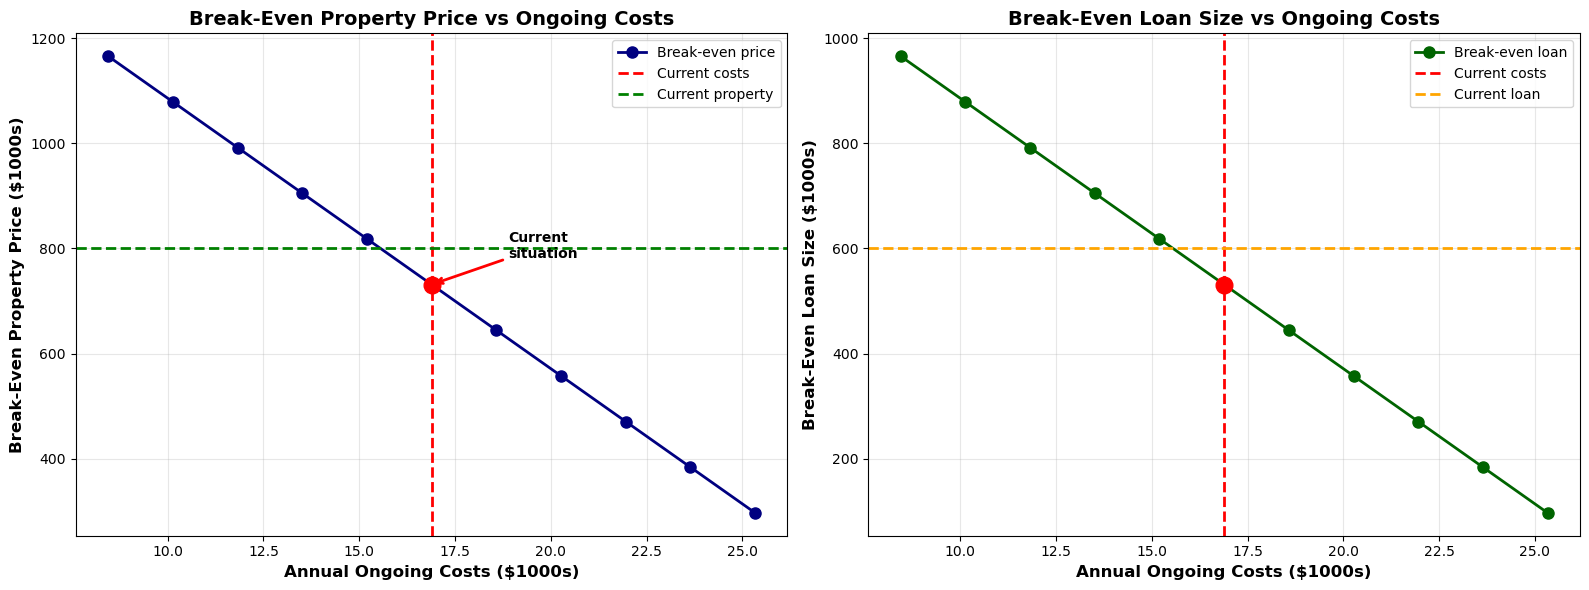


INTERPRETATION

📊 Current situation:
   Property price: $800,000
   Break-even price: $731,511
   Margin: $68,489

✓ You're $68,489 above break-even
   → Buying is the better choice


TypeError: only integer scalar arrays can be converted to a scalar index

In [ ]:
# Visualize the sensitivity analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Break-even price vs ongoing costs
cost_values = current_ongoing * cost_multipliers / 1000  # in thousands
valid_mask = ~np.isnan(breakeven_prices)

ax1.plot(cost_values[valid_mask], np.array(breakeven_prices)[valid_mask]/1000, 
         'o-', linewidth=2, markersize=8, color='navy', label='Break-even price')
ax1.axvline(x=current_ongoing/1000, color='red', linestyle='--', linewidth=2, label='Current costs')
ax1.axhline(y=property_price/1000, color='green', linestyle='--', linewidth=2, label='Current property')

ax1.set_xlabel('Annual Ongoing Costs ($1000s)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Break-Even Property Price ($1000s)', fontsize=12, fontweight='bold')
ax1.set_title('Break-Even Property Price vs Ongoing Costs', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best', fontsize=10)

# Mark the current point
current_idx = np.argmin(np.abs(cost_multipliers - 1.0))
ax1.plot(current_ongoing/1000, breakeven_prices[current_idx]/1000, 
         'ro', markersize=12, zorder=5)
ax1.annotate('Current\nsituation', 
            xy=(current_ongoing/1000, breakeven_prices[current_idx]/1000),
            xytext=(current_ongoing/1000 + 2, breakeven_prices[current_idx]/1000 + 50),
            fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red', lw=2))

# RIGHT: Break-even loan vs ongoing costs
ax2.plot(cost_values[valid_mask], np.array(breakeven_loans)[valid_mask]/1000, 
         'o-', linewidth=2, markersize=8, color='darkgreen', label='Break-even loan')
ax2.axvline(x=current_ongoing/1000, color='red', linestyle='--', linewidth=2, label='Current costs')
ax2.axhline(y=P/1000, color='orange', linestyle='--', linewidth=2, label='Current loan')

ax2.set_xlabel('Annual Ongoing Costs ($1000s)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Break-Even Loan Size ($1000s)', fontsize=12, fontweight='bold')
ax2.set_title('Break-Even Loan Size vs Ongoing Costs', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best', fontsize=10)

# Mark the current point
ax2.plot(current_ongoing/1000, breakeven_loans[current_idx]/1000, 
         'ro', markersize=12, zorder=5)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
print(f"\n📊 Current situation:")
print(f"   Property price: ${property_price:,.0f}")
print(f"   Break-even price: ${breakeven_prices[current_idx]:,.0f}")
print(f"   Margin: ${property_price - breakeven_prices[current_idx]:,.0f}")

if property_price > breakeven_prices[current_idx]:
    print(f"\n✓ You're ${property_price - breakeven_prices[current_idx]:,.0f} above break-even")
    print(f"   → Buying is the better choice")
else:
    print(f"\n✗ You're ${breakeven_prices[current_idx] - property_price:,.0f} below break-even")
    print(f"   → Renting is the better choice")

# Calculate sensitivity
valid_prices = np.array(breakeven_prices)[valid_mask]
valid_costs = cost_values[valid_mask]
price_change = valid_prices[-1] - valid_prices[0]
cost_change = valid_costs[-1] - valid_costs[0]
sensitivity = price_change / cost_change

print(f"\n📈 Sensitivity:")
print(f"   For every $1,000 increase in annual costs,")
print(f"   break-even property price DECREASES by ${-sensitivity:,.0f}")
print(f"\n   This makes sense: higher costs mean you need LESS leverage")
print(f"   (lower property price) to justify the higher ongoing expenses")

## Multi-Factor Sensitivity: Property Price & Rent

Let's create a heatmap showing when buying is better across different property prices and rent levels.

In [ ]:
# Create a grid of property prices and rent levels
property_prices_test = np.linspace(600000, 1000000, 15)
weekly_rents_test = np.linspace(400, 800, 15)

# Calculate wealth difference for each combination
wealth_diff_grid = np.zeros((len(weekly_rents_test), len(property_prices_test)))

for i, rent in enumerate(weekly_rents_test):
    for j, price in enumerate(property_prices_test):
        diff = wealth_difference_at_price(
            price, deposit, rent, rates_annual, body_corp_annual,
            interest_rate, loan_term_years, 24,
            property_growth_rate, investment_return_rate
        )
        wealth_diff_grid[i, j] = diff

# Create heatmap
fig, ax = plt.subplots(figsize=(14, 10))

# Convert to thousands for better readability
wealth_diff_grid_k = wealth_diff_grid / 1000

im = ax.imshow(wealth_diff_grid_k, aspect='auto', cmap='RdYlGn', 
               extent=[property_prices_test[0]/1000, property_prices_test[-1]/1000,
                      weekly_rents_test[0], weekly_rents_test[-1]],
               origin='lower', vmin=-50, vmax=50)

# Add contour line at 0 (break-even line)
CS = ax.contour(property_prices_test/1000, weekly_rents_test, wealth_diff_grid_k, 
                levels=[0], colors='black', linewidths=3)
ax.clabel(CS, inline=True, fontsize=12, fmt='Break-even')

# Mark current situation
ax.plot(property_price/1000, weekly_rent, 'b*', markersize=20, 
        markeredgecolor='white', markeredgewidth=2, label='Current property')

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Wealth Advantage of Buying ($1000s)', fontsize=12, fontweight='bold')

# Labels and title
ax.set_xlabel('Property Price ($1000s)', fontsize=12, fontweight='bold')
ax.set_ylabel('Weekly Rent ($)', fontsize=12, fontweight='bold')
ax.set_title('Buy vs Rent: Wealth Difference After 2 Years\n(Green = Buying Better, Red = Renting Better)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3, color='white', linewidth=0.5)

plt.tight_layout()
plt.show()

print("="*70)
print("HEATMAP INTERPRETATION")
print("="*70)
print(f"\n🎯 Current property (blue star):")
print(f"   Price: ${property_price:,.0f}")
print(f"   Rent: ${weekly_rent:,.0f}/week")

# Find current wealth difference
current_diff = wealth_difference_at_price(
    property_price, deposit, weekly_rent, rates_annual, body_corp_annual,
    interest_rate, loan_term_years, 24,
    property_growth_rate, investment_return_rate
)

if current_diff > 0:
    print(f"   Buying advantage: ${current_diff:,.0f}")
    print(f"   → Buying is better ✓")
else:
    print(f"   Renting advantage: ${-current_diff:,.0f}")
    print(f"   → Renting is better ✗")

print(f"\n📊 Key insights from the heatmap:")
print(f"   • Black line = break-even (buy = rent)")
print(f"   • Green zone = buying wins")
print(f"   • Red zone = renting wins")
print(f"\n   Buying becomes MORE attractive when:")
print(f"   1. Property price is HIGHER (more leverage)")
print(f"   2. Rent is HIGHER (savings from buying increase)")
print(f"\n   Renting becomes MORE attractive when:")
print(f"   1. Property price is LOWER (less leverage benefit)")
print(f"   2. Rent is LOWER (cheaper to rent)")